In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from minimos_cuadrados import minimos_cuadrados
from minimos_cuadrado_vid import minimos_cuadrados_vid
from spline_cubico_natural_vid import spline_cubico_natural_vid

In [59]:
# Cargar el dataframe con las variables que se van a utilizar
df = pd.read_csv(r"asthma_disease_data.csv")
pd.set_option('display.max_rows', None)
cols = [
    "Age", "Gender", "PollutionExposure", "PollenExposure", "DustExposure",
    "FamilyHistoryAsthma", "Smoking", "PhysicalActivity",
    "DietQuality", "HistoryOfAllergies" , "Diagnosis"
]
# Vuelve a cargar el dataframe con las variables seleccionadas
df = pd.read_csv("asthma_disease_data.csv", usecols=cols)
# Elimina las filas con valores nulos
df = df.dropna()
print(df)

      Age  Gender  Smoking  PhysicalActivity  DietQuality  PollutionExposure  \
0      63       0        0          0.894448     5.488696           7.388481   
1      26       1        0          5.897329     6.341014           1.969838   
2      57       0        0          6.739367     9.196237           1.460593   
3      40       1        0          1.404503     5.826532           0.581905   
4      61       0        0          4.604493     3.127048           0.980875   
5      21       0        0          0.470044     1.759118           1.711446   
6      45       1        1          9.371784     7.030507           7.664306   
7      26       0        1          8.344096     1.626484           6.939046   
8      49       1        0          2.690256     3.920034           3.180421   
9      45       1        0          2.895720     2.607700           1.711722   
10     27       0        0          3.900003     1.748193           1.546419   
11     62       1        0          6.63

In [60]:
# Muestra las dimensiones del dataframe
df.shape

(2392, 11)

In [61]:
# Muestra la información detallada del dataframe para verificar los tipos de datos y si existen valores nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2392 non-null   int64  
 1   Gender               2392 non-null   int64  
 2   Smoking              2392 non-null   int64  
 3   PhysicalActivity     2392 non-null   float64
 4   DietQuality          2392 non-null   float64
 5   PollutionExposure    2392 non-null   float64
 6   PollenExposure       2392 non-null   float64
 7   DustExposure         2392 non-null   float64
 8   FamilyHistoryAsthma  2392 non-null   int64  
 9   HistoryOfAllergies   2392 non-null   int64  
 10  Diagnosis            2392 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 205.7 KB


In [62]:
# Agrupa la proporcion de diagnóstico por edad
# Esto asume que 'Diagnosis' es una columna binaria donde 1 indica diagnóstico positivo y 0 negativo.
prevalencia_edad = df.groupby('Age')['Diagnosis'].mean()
x = prevalencia_edad.index.tolist()
y = prevalencia_edad.values.tolist()
print(spline_cubico_natural_vid(x, y, 4))
print(minimos_cuadrados(x, y, 4))

S_0(x) = 0.0308*x**3 - 0.462*x**2 + 2.2018*x - 3.1575
S_1(x) = -0.0756*x**3 + 1.4532*x**2 - 9.2895*x + 19.8255
S_2(x) = 0.1173*x**3 - 2.5977*x**2 + 19.0668*x - 46.3392
S_3(x) = -0.1476*x**3 + 3.76*x**2 - 31.7955*x + 89.2952
S_4(x) = 0.1124*x**3 - 3.2601*x**2 + 31.3862*x - 100.2521
S_5(x) = -0.0163*x**3 + 0.601*x**2 - 7.2257*x + 28.457
S_6(x) = -0.0534*x**3 + 1.8252*x**2 - 20.6909*x + 77.8261
S_7(x) = 0.0373*x**3 - 1.44*x**2 + 18.4915*x - 78.9035
S_8(x) = -0.0113*x**3 + 0.4553*x**2 - 6.1462*x + 27.8551
S_9(x) = 0.0505*x**3 - 2.1401*x**2 + 30.1868*x - 141.6876
S_10(x) = -0.1188*x**3 + 5.4784*x**2 - 84.0907*x + 429.6999
S_11(x) = 0.1586*x**3 - 7.8368*x**2 + 128.9525*x - 706.5305
S_12(x) = -0.1629*x**3 + 8.5597*x**2 - 149.788*x + 872.999
S_13(x) = 0.1295*x**3 - 7.2299*x**2 + 134.4248*x - 832.2778
S_14(x) = -0.0729*x**3 + 4.3068*x**2 - 84.7707*x + 555.9496
S_15(x) = 0.0239*x**3 - 1.5013*x**2 + 31.3932*x - 218.4884
S_16(x) = 0.029*x**3 - 1.8226*x**2 + 38.1405*x - 265.7196
S_17(x) = -0.0736*x

In [63]:
# Agrupa la proporcion de diagnóstico por genero
prevalencia_genero = df.groupby('Gender')['Diagnosis'].mean()
x = prevalencia_genero.index.tolist()
y = prevalencia_genero.values.tolist()
print(spline_cubico_natural_vid(x, y, 4))
print(minimos_cuadrados(x, y, 4))

S_0(x) = 0.0014*x + 0.0512
None
(0.0014, 0.0512)


In [64]:
# Agrupa la proporcion de diagnóstico por consumo de tabaco
prevalencia_fumadores = df.groupby('Smoking')['Diagnosis'].mean()
x = prevalencia_fumadores.index.tolist()    
y = prevalencia_fumadores.values.tolist()
print(minimos_cuadrados_vid(x, y, 4))
print(minimos_cuadrados(x, y, 4))

(0.0536, -0.0123)
(-0.0123, 0.0536)


In [65]:
# Agrupa la proporcion de diagnóstico por actividad física
prevalencia_act_fisica = df.groupby('PhysicalActivity')['Diagnosis'].mean()
x = prevalencia_act_fisica.index.tolist()
y = prevalencia_act_fisica.values.tolist()
print(minimos_cuadrados_vid(x, y, 4))  
print(minimos_cuadrados(x, y, 4))

(0.0499, 0.0004)
(0.0004, 0.0499)


In [66]:
# Agrupa la proporcion de diagnóstico por calidad de la dieta
prevalencia_calidad_dieta = df.groupby('DietQuality')['Diagnosis'].mean()
x = prevalencia_calidad_dieta.index.tolist()  
y = prevalencia_calidad_dieta.values.tolist()
print(minimos_cuadrados_vid(x, y, 4))
print(minimos_cuadrados(x, y, 4))     

(0.053, -0.0002)
(-0.0002, 0.053)


In [67]:
# La agrupación con la proporción de diagnóstico con la contaminación ambiental (polución)
prevalencia_polucion = df.groupby('PollutionExposure')['Diagnosis'].mean()
x = prevalencia_polucion.index.tolist()
y = prevalencia_polucion.index.tolist()
print(spline_cubico_natural_vid(x, y, 4))
print(minimos_cuadrados_vid(x, y, 4))

S_0(x) = 1.0*x - 2.15049107152999e-5
S_1(x) = 1.0*x + 2.44652834888999e-5
S_2(x) = 1.0*x - 1.10248691020005e-5
S_3(x) = 1.0*x + 4.9423085101901e-5
S_4(x) = 1.0*x - 2.23228808295985e-5
S_5(x) = 1.0*x + 5.93143623610348e-6
S_6(x) = 1.0*x - 4.25493198243018e-5
S_7(x) = 1.0*x - 2.11419280220018e-5
S_8(x) = 1.0*x - 1.45569216725983e-5
S_9(x) = 1.0*x + 2.29705382246009e-5
S_10(x) = 1.0*x + 4.22723865251967e-5
S_11(x) = 1.0*x - 3.40760238584994e-5
S_12(x) = 1.0*x - 3.34513671629982e-6
S_13(x) = 1.0*x + 3.26737282428033e-5
S_14(x) = 1.0*x - 1.90509917765008e-5
S_15(x) = 1.0*x - 3.52531704134046e-5
S_16(x) = 1.0*x + 3.27063799819005e-5
S_17(x) = 1.0*x - 3.05876302560126e-6
S_18(x) = 1.0*x + 3.68599904648909e-5
S_19(x) = 1.0*x + 4.70443173267998e-5
S_20(x) = 1.0*x - 1.37070011650975e-5
S_21(x) = 1.0*x + 2.0404773278887e-5
S_22(x) = 1.0*x - 7.47024189409751e-6
S_23(x) = 1.0*x + 3.69866448529099e-5
S_24(x) = 1.0*x - 1.56816388434955e-5
S_25(x) = 1.0*x + 3.61461759254e-5
S_26(x) = 1.0*x + 3.8011815

In [68]:
# La agrupación con la proporción de diagnóstico con la exposición al polen.
prevalencia_polen = df.groupby('PollenExposure')['Diagnosis'].mean()
x = prevalencia_polen.index.tolist()    
y = prevalencia_polen.values.tolist()
print(minimos_cuadrados_vid(x, y, 4))
print(minimos_cuadrados_vid(x, y, 4))

(0.0459, 0.0012)
(0.0459, 0.0012)


In [69]:
# La agrupación con la proporción de diagnóstico con la exposición al polvo.
prevalencia_polvo = df.groupby('DustExposure')['Diagnosis'].mean()
x = prevalencia_polvo.index.tolist()
y = prevalencia_polvo.values.tolist()
print(spline_cubico_natural_vid(x, y, 4))
print(minimos_cuadrados_vid(x, y, 4))

S_0(x) = 0
S_1(x) = 0
S_2(x) = 0
S_3(x) = 0
S_4(x) = 0
S_5(x) = 0
S_6(x) = 0
S_7(x) = 0
S_8(x) = 0
S_9(x) = 0
S_10(x) = 0
S_11(x) = 0
S_12(x) = 0
S_13(x) = 0
S_14(x) = 0
S_15(x) = 0
S_16(x) = 0
S_17(x) = 0
S_18(x) = 0
S_19(x) = 0
S_20(x) = 0
S_21(x) = -0.0001*x**3 + 2.50832710243252e-5*x**2 - 2.0972349509325e-6*x + 5.84505696399191e-8
S_22(x) = 0.0009*x**3 - 0.0002336255972853*x**2 + 2.02151554470049e-5*x - 5.8305898339774e-7
S_23(x) = -0.0048*x**3 + 0.00127018524077674*x**2 - 0.000112039621242157*x + 3.2942378075001e-6
S_24(x) = 0.0126*x**3 - 0.00338597398561276*x**2 + 0.000303302111937735*x - 9.05619983071059e-6
S_25(x) = -0.0404*x**3 + 0.0111770319327039*x**2 - 0.00103066041934557*x + 3.16773831841069e-5
S_26(x) = 0.0381*x**3 - 0.0108714468476792*x**2 + 0.00103366891130283*x - 3.27500949202933e-5
S_27(x) = -0.1228*x**3 + 0.0369505552070256*x**2 - 0.00370546560832641*x + 0.000123841422448989
S_28(x) = 0.2838*x**3 - 0.0906149914574728*x**2 + 0.0096411988217499*x - 0.000341829866936278

In [70]:
# La agrupación con la proporción de diagnóstico con el historial familar con respecto al Asma.
prevalencia_asma = df.groupby('FamilyHistoryAsthma')['Diagnosis'].mean()
x = prevalencia_asma.index.tolist()
y = prevalencia_asma.values.tolist()
print(spline_cubico_natural_vid(x, y, 4))
print(minimos_cuadrados_vid(x, y, 4))


S_0(x) = 0.052 - 0.0006*x
None
(0.052, -0.0006)


In [71]:
# La agrupación con la proporción de diagnóstico con el historial de alergias del paciente.
prevalencia_genero = df.groupby('HistoryOfAllergies')['Diagnosis'].mean()
x = prevalencia_genero.index.tolist()
y = prevalencia_genero.values.tolist()
print(spline_cubico_natural_vid(x, y, 4))
print(minimos_cuadrados_vid(x, y, 4))

S_0(x) = 0.0522 - 0.0009*x
None
(0.0522, -0.0009)


<Figure size 1000x600 with 0 Axes>

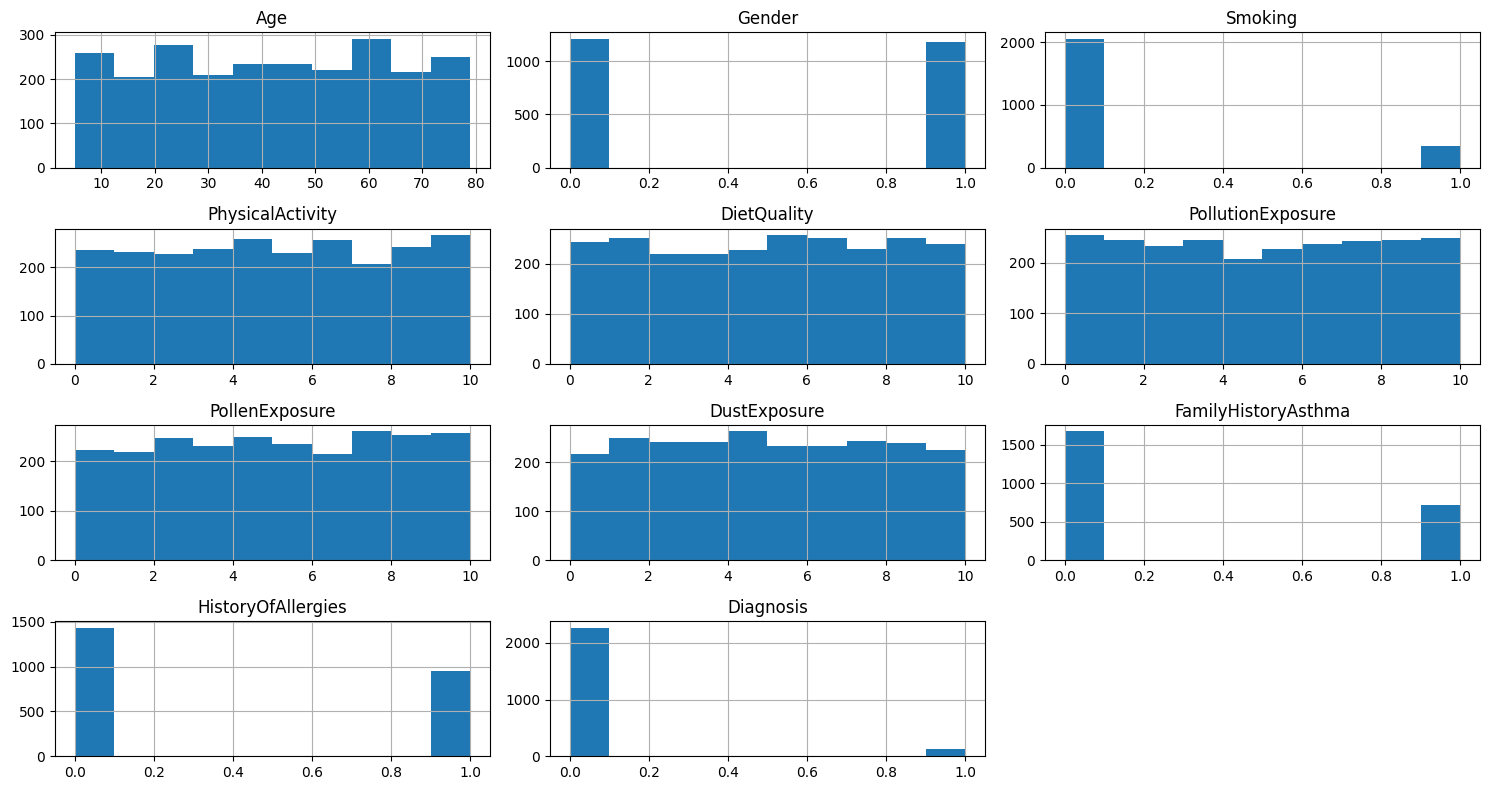

In [72]:
# Visualización de la distribución de los datos
plt.figure(figsize=(10, 6))
df.describe()
df.hist(figsize=(15, 8))
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Grupo de Edad')

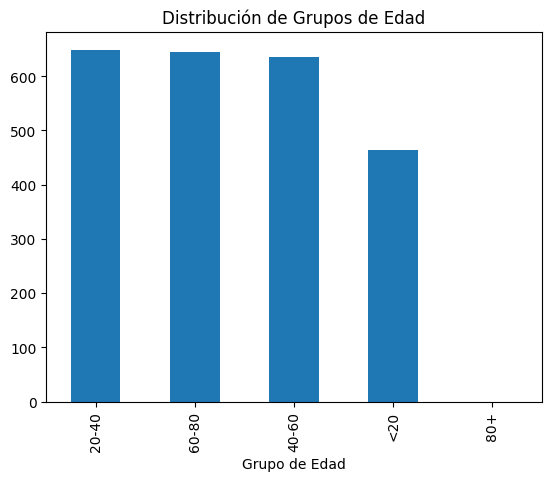

In [73]:
# Agrupación de edades en grupos
max_edad = max(80, df['Age'].max()) + 1
rangos = [0, 20, 40, 60, 80, max_edad]
labels = ['<20', '20‑40', '40‑60', '60‑80', '80+']
df['AgeGroup'] = pd.cut(df['Age'], bins=rangos, labels=labels, right=False)
df['AgeGroup'].value_counts().plot(kind='bar', title='Distribución de Grupos de Edad')
plt.xlabel('Grupo de Edad')

C:\Users\mauri\AppData\Local\Temp\ipykernel_17904\808225620.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia_edad = df.groupby('AgeGroup')['Diagnosis'].mean()


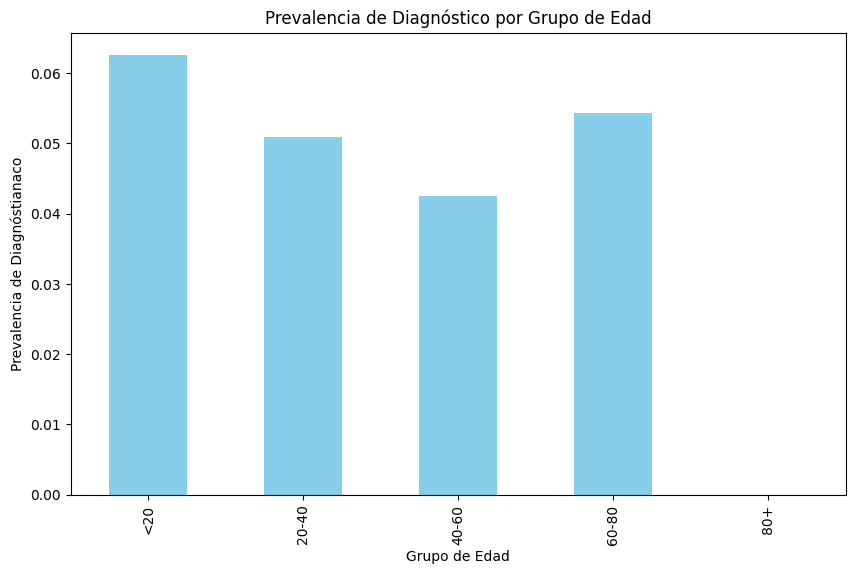

In [74]:
prevalencia_edad = df.groupby('AgeGroup')['Diagnosis'].mean()
plt.figure(figsize=(10, 6))
prevalencia_edad.plot(kind='bar', color='skyblue')
plt.title('Prevalencia de Diagnóstico por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Prevalencia de Diagnóstianaco')
plt.show()